# Sequence To Sequence Modeling

# Agenda

1. [[Intro] Generative NLP Tasks](#intro)
2. [[Theory] Sequence-To-Sequence Transformers](#seq2seq)
3. [[Theory] Inference VS Train Sampling](#sampling)
4. [[Practice] Machine Translation Training](#translation)
5. [[Practice] Sequence-To-Sequence Inference Examples](#inference)

<a id='intro'></a>
# [Intro] Generative NLP Tasks

## Generative vs Discriminative

**Generative Models**:
Generative models aim to understand how data is generated by estimating the joint probability distribution $p(X, Y)$ of input features $X$ and output labels $Y$, or just $p(X)$ if there are no labels. They are versatile and can be used for data generation and imputing missing data.

**Discriminative Models**:
Discriminative models, on the other hand, focus on modeling the conditional probability  $p(Y | X)$ of output labels $Y$ given input features $X$. They aim to learn the decision boundary that separates different classes and are primarily used for classification tasks.

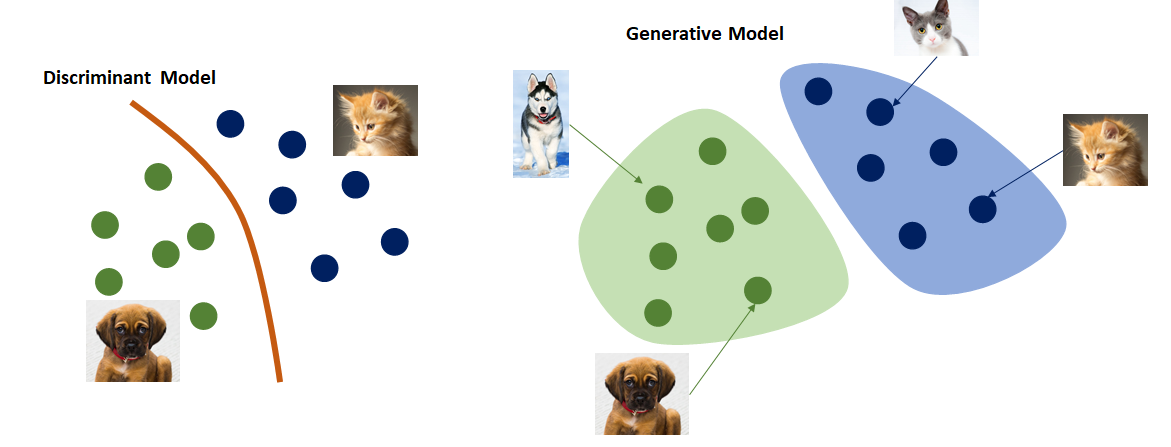

A generative model includes the distribution of the data itself, and **tells you how likely a given example is**. For example, models that predict the next word in a sequence are typically generative models  because they can assign a probability to a sequence of words.

A discriminative model ignores the question of whether a given instance is likely, and just tells you how likely a label is to apply to the instance.


**The Generative Modeling Framework**

* We have a dataset of observations $X$.

* We assume that the observations have been generated according to some unknown distribution, $p_{data}$.

* A generative model $p_{model}$  tries to mimic $p_{data}$. If we achieve this goal, we can sample from $p_{model}$ to generate observations that appear to have been drawn from $p_{data}$.

* We are impressed by $p_{model}$ if:

    * Rule 1: It can generate examples that appear to have been drawn from $p_{data}$.

    * Rule 2: It can generate examples that are suitably different from the observations in $X$. In other words, the model shouldn’t simply reproduce things it has already seen.



Generative models tackle a more difficult task than analogous discriminative models. **Generative models have to model more.**

A generative text model might need to understand intricate language nuances, such as word associations, grammar, and context. For instance, it should be able to infer that in the sentence *"The cat sat on the ___,"* the blank is likely to be filled with a noun, and it should consider contextual cues to predict what that noun might be. These complexities make generating text a demanding task for generative models.


### Next Token Prediction

It involves predicting the next word or character in a sequence of text given the preceding context. The language model will receive input tokens and will predict the next token. From an abstract point of view, predicting the next token is a multi-class classification task where there are many classes (50,257 classes for GPT-2 since these are all the possible tokens).

![next_token_gen.png](images/next_token_gen.png)

To make next token predictions, models often employ techniques like greedy search, beam search (which explores multiple potential continuations) and sampling (which randomly selects tokens with probabilities determined by the model). These techniques balance between generating coherent text and introducing diversity in output.


### Text Generation
This task involves generating text, which can be used for various applications, such as content creation, chatbots, and creative writing. Text can be generated from scratch or be conditioned on specific input.

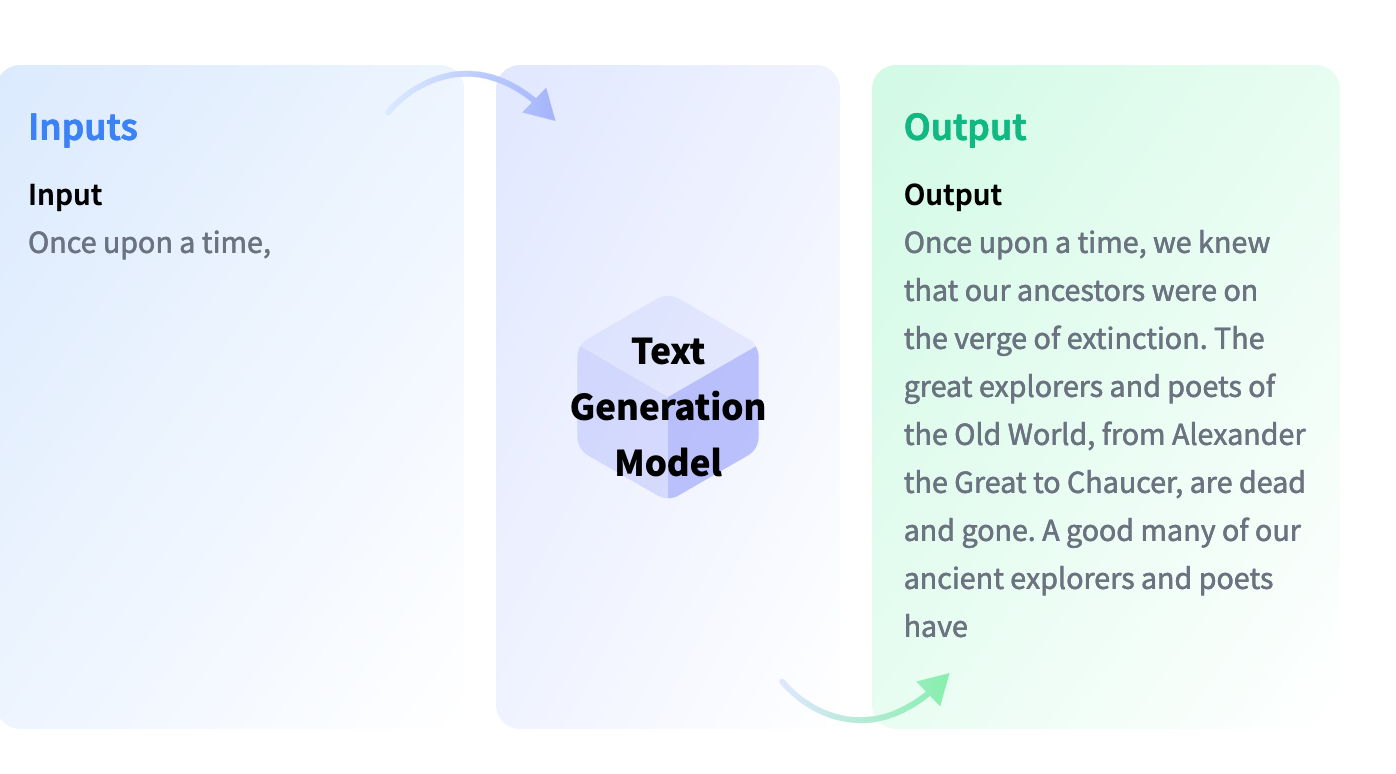

### Machine Translation
Generative models are used to automatically translate text from one language to another, enabling cross-lingual communication and content localization.

Machine Translation models, especially modern neural machine translation systems, operate by generating translations word by word or subsequence by subsequence, effectively predicting the next token based on the context established by the preceding words. This contextual prediction aligns with the fundamental principles of generative modeling, where the aim is to create text that is coherent, contextually relevant, and reflective of the source content.

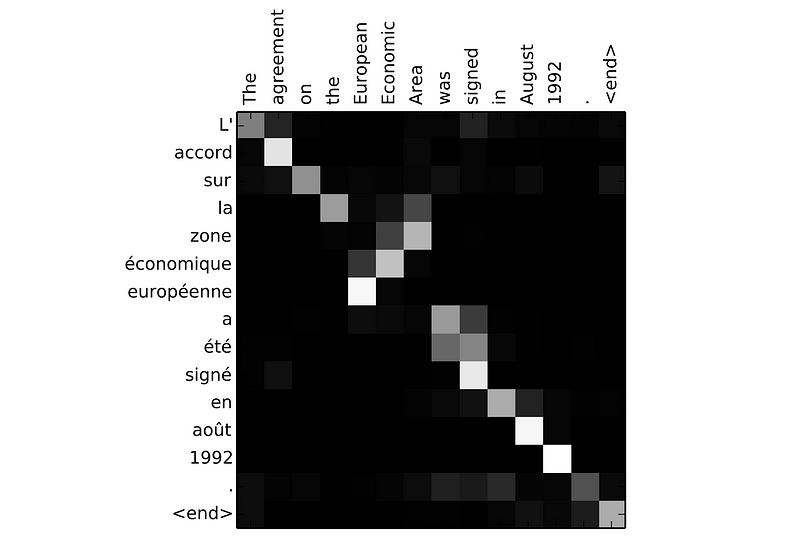

### Summarization
Automatic text summarization involves generating concise and coherent summaries of longer documents. This  involves generating a concise and coherent summary of a given text while interpreting and paraphrasing its content. Unlike extractive summarization, which selects and compiles existing sentences or phrases from the source text, abstractive summarization aims to create summaries in a more human-like manner. 

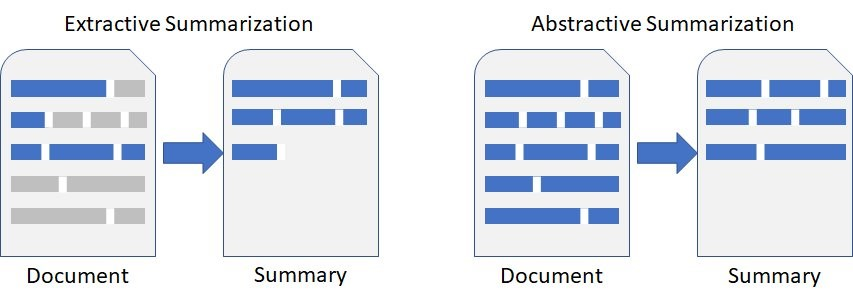

### Paraphrasing

Paraphrasing is the task of expressing the meaning of a source text into a new text by using different words and maintaining the semantic meaning. The goal might be to achieve greater clarity, to prevent plagiarism or to do data augmentation by generating related-but-different training data.

### Text style transfer

A task that focuses on changing the style or attributes of a given text while preserving its original content and meaning. This process involves transforming the text in terms of attributes like sentiment, formality, politeness, or even genre, all while maintaining the fundamental message conveyed by the source text.

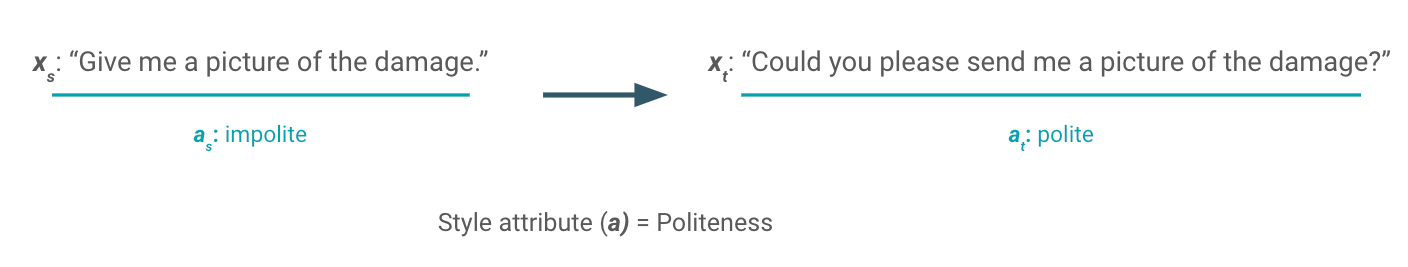

<a id='seq2seq'></a>
# [Theory] Sequence-To-Sequence Transformers

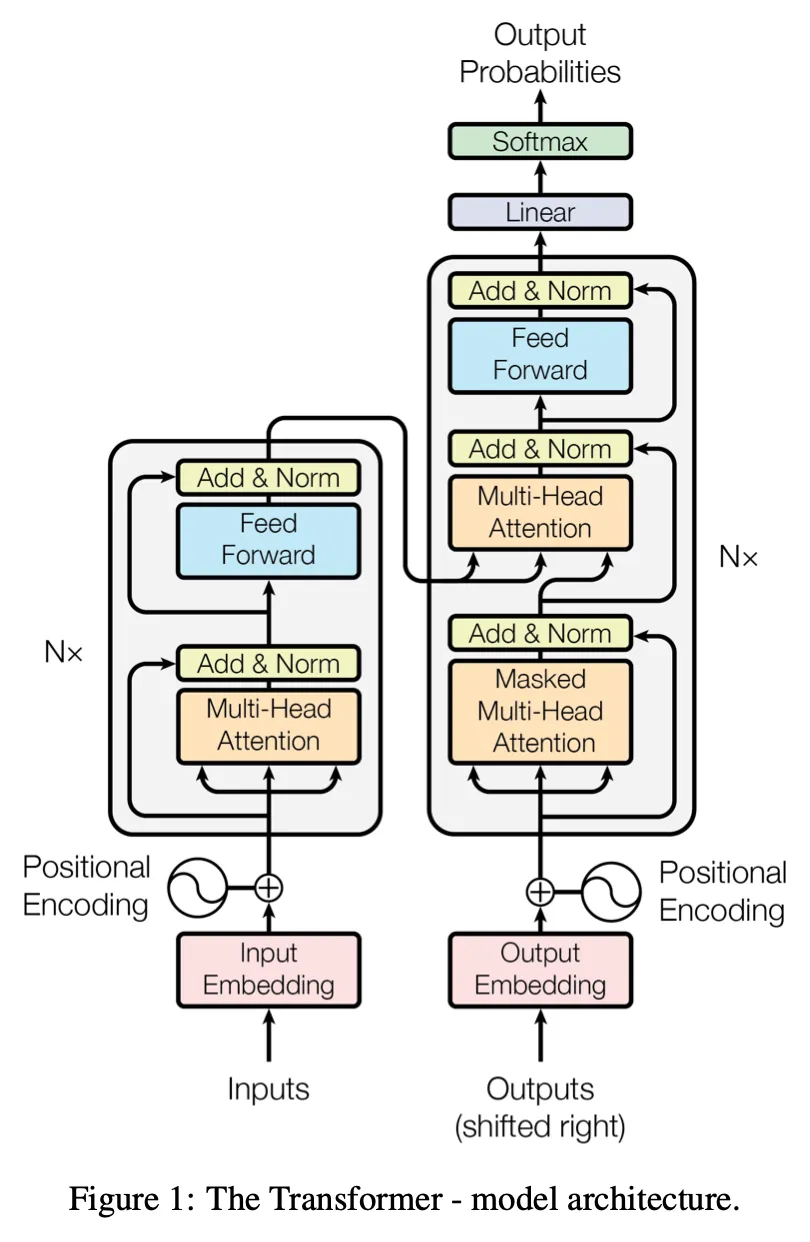

## mT5 model family

> **TODO**: Check the [paper](https://arxiv.org/pdf/2010.11934)
> 
> **TODO**: Check the [article](https://cameronrwolfe.substack.com/p/t5-text-to-text-transformers-part)

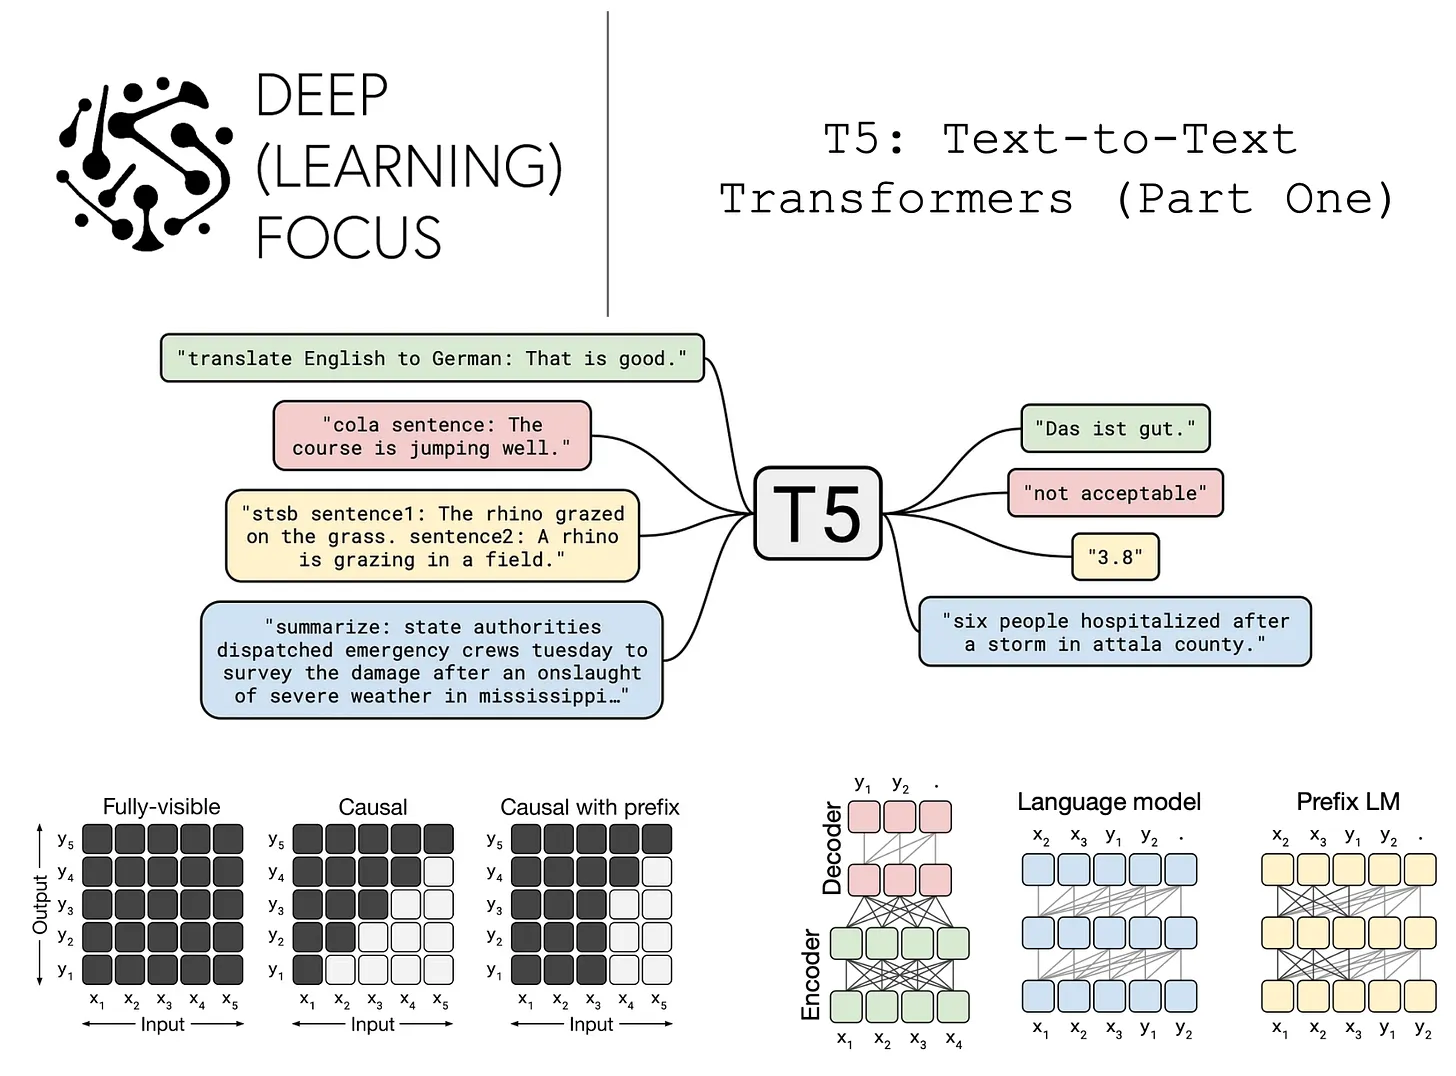

The **mT5** (Multilingual T5) model is a massively multilingual variant of the **T5** (Text-to-Text Transfer Transformer) model. It was developed to handle 101 languages using a text-to-text format for all NLP tasks. The model follows the same training paradigm as T5 but extends it to a diverse set of languages using a new dataset called **mC4** (Multilingual C4).

### Pretraining Data and Objective

### mC4 Dataset
- The mC4 dataset is a multilingual extension of **C4** (Common Crawl Cleaned), covering **101 languages**.
- Data was extracted from **Common Crawl**, applying **language identification** using `cld3`.
- Non-natural text (boilerplate, gibberish, etc.) was filtered out.
- **SentencePiece tokenization** was used, increasing vocabulary size to **250K subwords**.
- Lower-resource languages were **up-sampled** using a power-law function $ p(L) \propto |L|^{\alpha} $ with $ \alpha = 0.3 $ to balance training.


### Pretraining Task Details
#### Span Corruption
- Unlike standard **masked language modeling (MLM)**, which replaces individual tokens with a mask, mT5 applies **span corruption**, where **consecutive spans of tokens** are masked and the model reconstructs them.
- The span corruption follows a **Poisson distribution** with an **average span length of 3 tokens**.
- Masked spans are replaced with **unique sentinel tokens**, enabling the model to predict them in the correct order.
- This method improves **longer-range dependencies learning** and enhances **text generation capabilities**.

### Model Architecture
- mT5 follows the **encoder-decoder Transformer** architecture, similar to T5.
- Model sizes range from **300M** (Small) to **13B** (XXL).
- Supports both **encoder-based and generative tasks**.

## mBART model family

> **TODO**: Check the [paper](https://arxiv.org/pdf/2001.08210)

The **mBART** (Multilingual BART) model is a **sequence-to-sequence denoising autoencoder** designed for **multilingual neural machine translation (MT)**. It extends the BART model by pretraining on **large-scale monolingual corpora in multiple languages**, providing a **universal initialization** for machine translation tasks, both **supervised** and **unsupervised**.

### Pretraining Data and Objective

#### CC25 Dataset
- mBART is pretrained on **CC25**, a **subset of Common Crawl corpus** containing data from **25 languages**.
- The dataset covers **diverse language families** and **varied resource levels**.
- Language balancing was achieved by **up/down-sampling** text using:  
  $ \lambda_i = \frac{1}{p_i} \cdot \frac{p_i^\alpha}{\sum_i p_i^\alpha} $  
  where $ p_i $ is the proportion of language $ i $ in CC25 and $ \alpha = 0.7 $.  
- Tokenization is performed using **SentencePiece**, with a vocabulary of **250K subwords**.

### Pretraining Task: Denoising Autoencoding
mBART uses **denoising autoencoding** as its self-supervised pretraining objective. The model is trained to **reconstruct full sentences** from corrupted versions.

#### Corruption Methods
1. **Span Masking**:
   - Random spans of text are masked and replaced with a **mask token**.
   - **35%** of words are masked using a **Poisson-distributed span length** ($ \lambda = 3.5 $).
2. **Sentence Permutation**:
   - Sentence order within a document is randomly shuffled.
   - This forces the model to learn sentence-level dependencies.


### Model Architecture
- Standard **Transformer-based sequence-to-sequence** architecture.
- **12-layer encoder, 12-layer decoder**.
- Model size: **680M parameters**.

<a id='sampling'></a>
# [Theory] Inference VS Train Sampling

## Inference Sampling


### Auto-regressive generation inside Decoder

Approach when model generates text or language sequentially, word by word or token by token, with each word being dependent on the preceding words in the sequence is called auto-regressive. This approach is "auto-regressive" because the model uses its own previously generated words as context to predict and generate the next word. 

Auto-regressive language generation is based on the assumption that the probability distribution of a word sequence can be decomposed into the product of conditional next word distributions:
$$\large P(w_{1:T}|W_0) = \prod_{t=1}^T P(w_t|w_{1:t-1}, W_0),\;with\;w_{1:0}=∅$$

and $W_0$ being the initial context word sequence.

The length $T$ of the word sequence is usually determined on-the-fly and corresponds to the timestep $t=T$ the `<EOS>` token is generated from $P(w_t|w_{1:t-1}, W_0)$.

![ar](images/text-gen-diagram.png)


The GPT model is performing autoregressive text generation. In this context, they operate solely as decoders, producing text one word at a time based on the preceding context. This makes them well-suited for tasks like text completion, text generation, and natural language understanding.

### Ways of selecting tokens
#### Greedy search

Greedy search is the simplest decoding method. It selects the word with the highest probability as its next word $w_t=argmax_w P(w∣w_{1:t−1})$ at each timestep $t$.

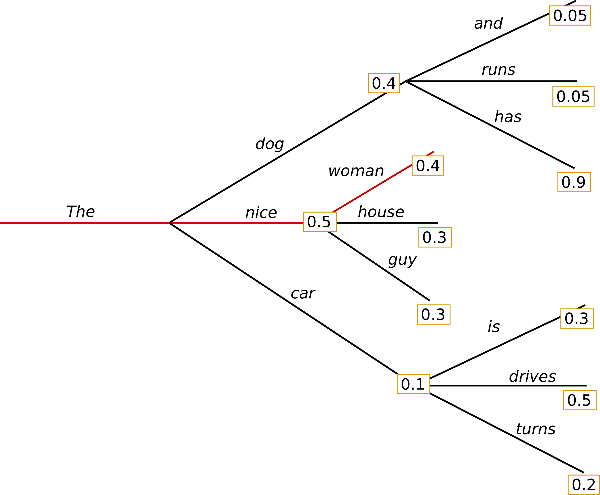

The major drawback of greedy search though is that it misses high probability words hidden behind a low probability word as can be seen in our sketch above:

#### Beam search
> **TODO**: read about beam search algorithm.

Beam search reduces the risk of missing hidden high probability word sequences by keeping the most likely num_beams of hypotheses at each time step and eventually choosing the hypothesis that has the overall highest probability. Let's illustrate with num_beams=2:  
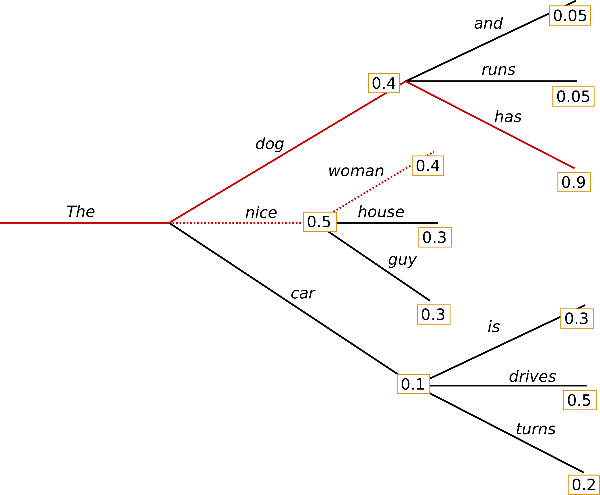

Beam search will always find an output sequence with higher probability than greedy search, but is not guaranteed to find the most likely output.

**BUT**

In open-ended generation, a couple of reasons have been brought forward why beam search might not be the best possible option:
1. Beam search can work very well in tasks where the length of the desired generation is more or less predictable as in machine translation or summarization - see [Murray et al. (2018)](https://arxiv.org/abs/1808.10006) and [Yang et al. (2018)](https://arxiv.org/abs/1808.09582). But this is not the case for open-ended generation where the desired output length can vary greatly, e.g. dialog and story generation.
2. Beam search heavily suffers from repetitive generation,but less then gready search. It can be controlled by using *n-gram penalties*, such as setting the probability of next words that could create an already seen n-gram to 0. But for many tasks it is still hard to do, for example in story generation, since finding a good trade-off between inhibiting repetition and repeating cycles of identical n-grams requires a lot of finetuning.
3. High quality human language does not follow a distribution of high probability next words. In other words, as humans, we want generated text to surprise us and not to be boring/predictable. 

#### Sampling

Sampling means randomly picking the next word $w_t$ according to its conditional probability distribution:

$$\large w_t∼P(w ∣ w_{1:t−1})$$

We can further improve this by modifing the pool of words we use for it, or by weighting the probabilities of words.

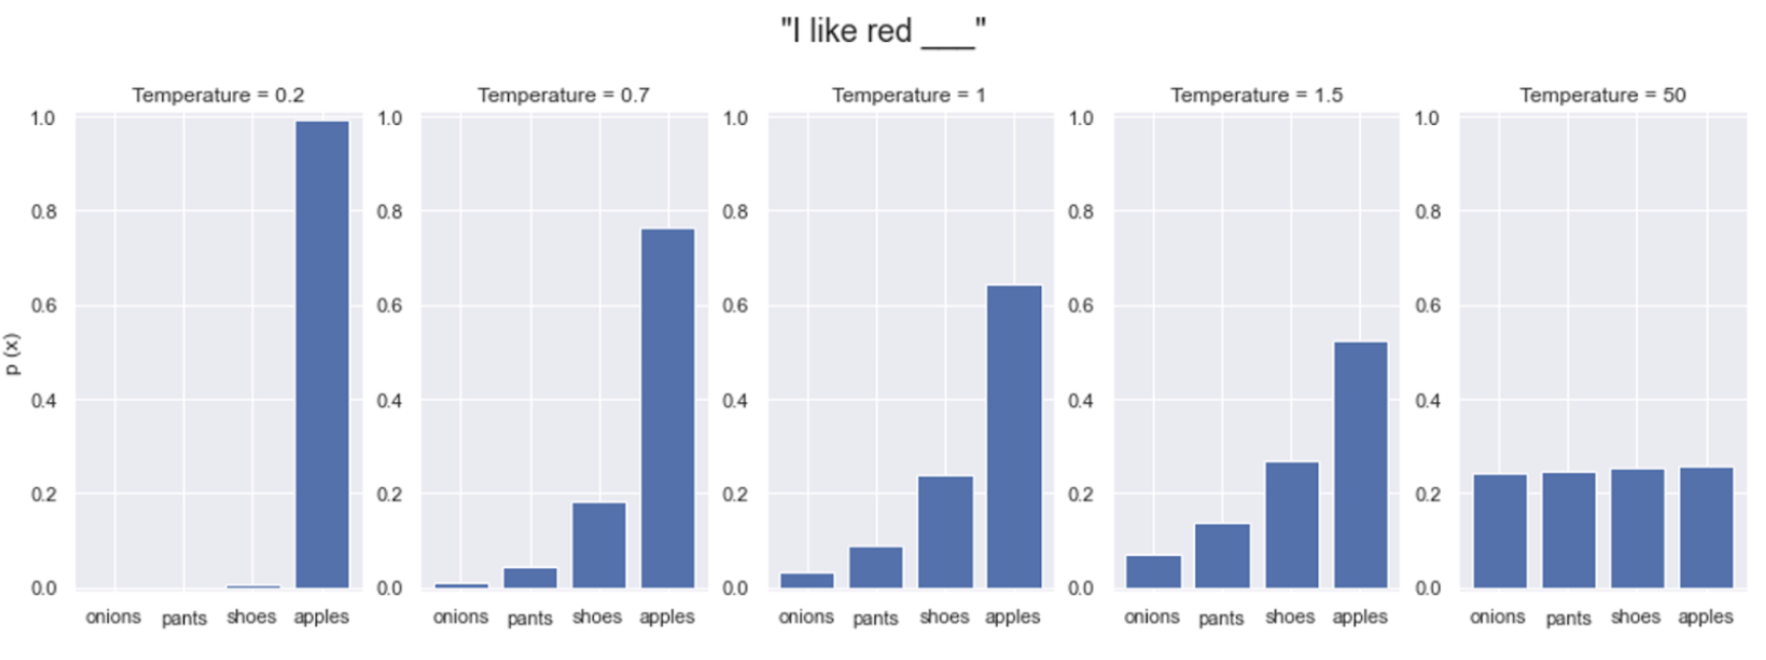

> **TODO**: read about *temprature* for [softmax](https://en.wikipedia.org/wiki/Softmax_function#Smooth_arg_max) function.

Commonly,Top-K sampling is performed:

1. The language model generates a probability distribution over the entire vocabulary for the next token in the sequence.

2. It ranks the tokens by their probabilities in descending order.

3. It identifies the top-k tokens with the highest probabilities. "k" is a predefined threshold that determines how many tokens to consider.

4. The model randomly samples from this set of top-k tokens to choose the next token in the sequence.

The top-k sampling method ensures that the next token is chosen from a restricted set of possibilities, which can be especially useful in text generation to control the output's quality and coherence. It balances between deterministic (by selecting only the top-k tokens) and more random (by allowing some variability in the selected token) generation.

#### Example with K=6:
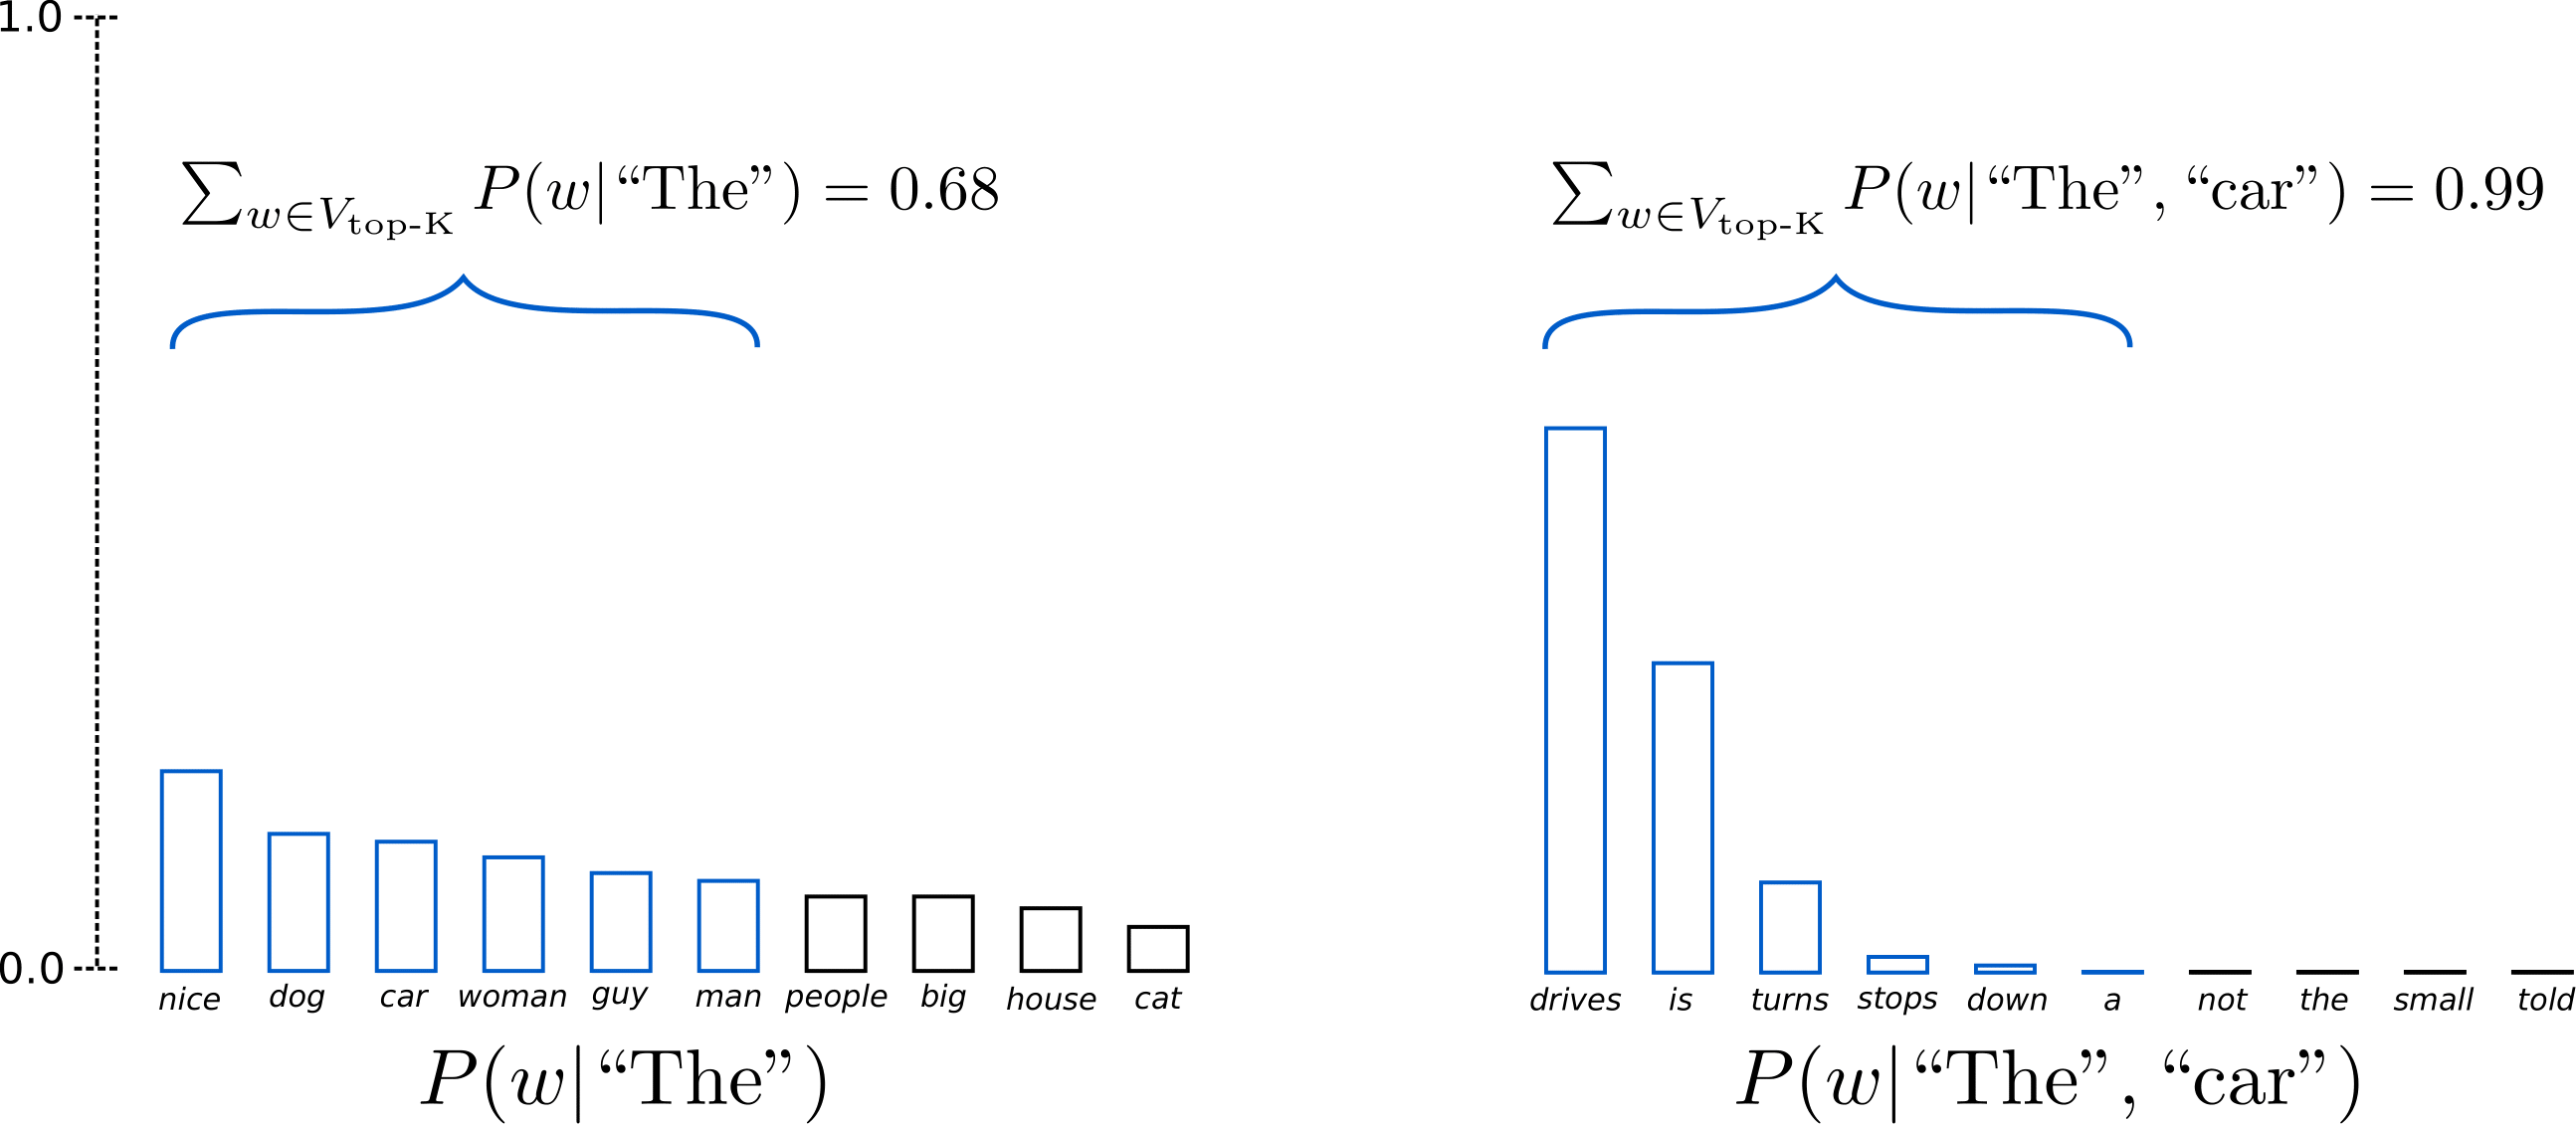

> **TODO**: read about top-p (nucleus) sampling.

## Training sampling

Seq2Seq models consist of two main components:
1. **Encoder**: Processes the input sequence and generates a fixed-length representation (context).
2. **Decoder**: Generates the output sequence step-by-step using the encoder’s context.

During training, the decoder **does not use its own generated tokens as input**. Instead, it always receives the **ground truth (gold) tokens** from the dataset. This method is called **teacher forcing**.

### **Encoder Pass**
- The input sequence $X = (x_1, x_2, ..., x_T)$ is passed through the encoder.
- The encoder transforms the input into a sequence of hidden states $H = (h_1, h_2, ..., h_T)$.
- The final hidden state (or attention-weighted states) serves as a **context vector**.

### **Decoder Pass (Teacher Forcing)**
- At timestep $t$, the decoder receives the **previous ground truth token** $y_{t-1}$ as input (instead of its own prediction).
- The decoder outputs a probability distribution $P(y_t | y_{<t}, H)$ for the next token.
- This prevents error accumulation and stabilizes training.

The **training objective** is to minimize the **negative log-likelihood** (NLL):

$$
\mathcal{L} = - \sum_{t=1}^{T} \log P(y_t | y_{<t}, H)
$$

### **Why No Sampling in Training?**
During training, we **already know the correct sequence**. Instead of feeding the decoder its own predicted outputs (which may be wrong and accumulate errors), we use the **true sequence** (teacher forcing). This:
- **Stabilizes training** by preventing the model from drifting off-course.
- **Speeds up convergence** by providing correct supervision at each step.
- **Encourages strong token-to-token dependencies** between input and output.


## **Key Difference Between Training and Inference**

| Stage        | Decoder Input             | Next Token Prediction | Sampling? |
|-------------|---------------------------|----------------------|-----------|
| **Training**  | Ground truth token $y_{t-1}$ | Predict next token $y_t$ | ❌ No |
| **Inference** | Model’s own previous prediction | Predict next token $y_t$ | ✅ Yes |

<a id='translation'></a>
# [Practice] Machine Translation Training

## Dataset
Dataset: https://huggingface.co/datasets/turuta/Multi30k-uk

Dataset Multi30k: English-Ukrainian variation
Multi30K dataset is designed to develop multilingual multimodal researches.

Initially this dataset extends the Flickr30K dataset by adding German translations. The descriptions were collected from a crowdsourcing platform, while the translations were collected from professionally contracted translators.

## Evaluation: BLEU
The **Bilingual Evaluation Understudy (BLEU)** metric is one of the most widely used automatic metrics for evaluating **machine translation (MT)** systems. Proposed by Papineni et al. (2002), BLEU measures how closely a generated translation matches one or more reference translations by computing **n-gram overlap** between them. It provides a quantitative assessment of translation quality without requiring human intervention.

### How BLEU is Computed
BLEU is based on **precision-based n-gram matching**, where the **number of overlapping n-grams** between the system-generated translation and the reference translation(s) is counted. However, to penalize short outputs that artificially inflate precision, BLEU includes a **brevity penalty** that discourages overly short translations. The final BLEU score is computed as:

$$
\text{BLEU} = \text{BP} \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)
$$

where:
- $p_n$ is the **precision of n-grams** (1-gram, 2-gram, etc.),
- $w_n$ are the **weights** assigned to different n-gram orders (typically uniform for $N=4$),
- **BP (brevity penalty)** is applied if the generated translation is **shorter** than the reference.

### Limitations of BLEU
Despite its popularity, BLEU has several limitations:
- **Recall-agnostic**: BLEU only considers **precision** and does not measure if important content is missing from the translation.
- **Insensitive to synonymy**: It treats all words **equally**, ignoring synonyms and paraphrases.
- **Word order dependency**: Since it relies on **exact n-gram matches**, minor reordering can lead to lower scores, even if the meaning is unchanged.

Despite these limitations, BLEU remains a standard metric for machine translation, especially for **benchmarking** and **comparing models**.

## Evaluation: BERT Score
The complete score matches each token in $(x)$ to a token in $(\hat{x})$ to compute recall, and each token in $(\hat{x})$ to a token in $(x)$ to compute precision. We use greedy matching to maximize the matching similarity score, where each token is matched to the most similar token in the other sentence. We combine precision and recall to compute an F1 measure. For a reference $(x)$ and candidate $(\hat{x})$, the recall, precision, and F1 scores are:

$$
R_{\text{BERT}} = \frac{1}{|x|} \sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} x_i^{\top} \hat{x}_j
$$

$$
P_{\text{BERT}} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} x_i^{\top} \hat{x}_j
$$

$$
F_{\text{BERT}} = \frac{2 P_{\text{BERT}} \cdot R_{\text{BERT}}}{P_{\text{BERT}} + R_{\text{BERT}}}
$$

Previous work on similarity measures demonstrated that rare words can be more indicative for sentence similarity than common words. BERTscore enables us to easily incorporate importance weighting. Given M reference sentences $(\{x^{(i)}\}_{i=1}^M)$, the idf score of a word-piece token \( w \) is:

$$
\text{idf}(w) = -\log \frac{1}{M} \sum_{i=1}^M \mathbb{I}[w \in x^{(i)}],
$$


Illustration of the computation of the recall metric:
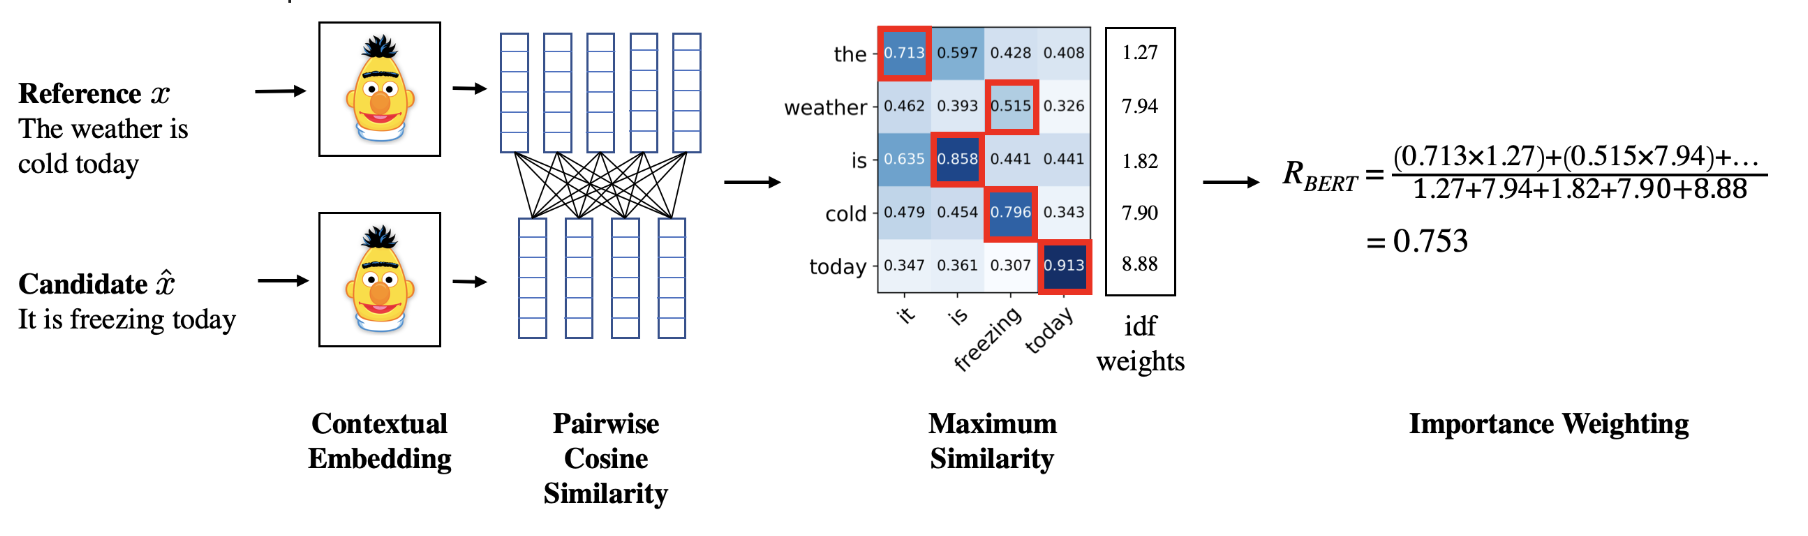

In [1]:
import wandb

wandb.init(
    project="iasa-nlp-lecture",
    entity="bazdyrev99-igor-sikorsky-kyiv-polytechnic-institute", 
    name='t5-base-uk-en'
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: bazdyrev99 (IASA-BA-Diploma-Ivan-Bashtovyi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
from datasets import Dataset

dataset = Dataset.from_json('/home/abazdyrev/pretrain_data/Multi30k-uk/train.json')
dataset

Dataset({
    features: ['en', 'uk'],
    num_rows: 29000
})

In [3]:
import torch
from datasets import load_dataset
import evaluate
from transformers import (
    MT5ForConditionalGeneration,
    MT5Tokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

model_name = "google/mt5-large"
tokenizer = MT5Tokenizer.from_pretrained(model_name)
model = MT5ForConditionalGeneration.from_pretrained(model_name)
MAX_LEN = 256

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'T5Tokenizer'. 
The class this function is called from is 'MT5Tokenizer'.
You are using the default legacy behaviour of the <class 'transformers.models.mt5.tokenization_mt5.MT5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [4]:
def preprocess_function(examples):
    # Add the task-specific prefix to each Ukrainian text.
    inputs = ["translate Ukrainian to English: " + text for text in examples["uk"]]
    targets = examples["en"]
    # Tokenize without padding (dynamic padding will be applied in the collator)
    model_inputs = tokenizer(inputs, max_length=MAX_LEN, truncation=True, padding=False)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=MAX_LEN, truncation=True, padding=False)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Tokenize the dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Split the dataset into training and evaluation sets
split_datasets = tokenized_dataset.train_test_split(test_size=0.05)
train_dataset = split_datasets["train"]
eval_dataset = split_datasets["test"]

In [5]:
import evaluate
import numpy as np
from datasets import load_dataset

bleu_score = evaluate.load("bleu")
bert_score = evaluate.load("bertscore")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]

    return preds, labels

def compute_metrics(eval_preds):
    try:
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]

        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    
        # Replace -100 in the labels as we can't decode them.
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
        # Some simple post-processing
        decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)
    
        result_bleu = bleu_score.compute(predictions=decoded_preds, references=decoded_labels)
        result_bertscore = bert_score.compute(predictions=decoded_preds, references=decoded_labels, lang="en")
        result = {
            "bleu": result_bleu["bleu"], 
            "bertscore_f1": np.mean(result_bertscore["f1"]),
            "bertscore_precision": np.mean(result_bertscore["precision"]),
            "bertscore_recall": np.mean(result_bertscore["recall"])
        }
    
        prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]
        result["gen_len"] = np.mean(prediction_lens)
        result = {k: round(v, 4) for k, v in result.items()}
        return result
    except Exception as exc:
        print(str(exc))

print(bleu_score)
print(bert_score)

EvaluationModule(name: "bleu", module_type: "metric", features: [{'predictions': Value(dtype='string', id='sequence'), 'references': Sequence(feature=Value(dtype='string', id='sequence'), length=-1, id='references')}, {'predictions': Value(dtype='string', id='sequence'), 'references': Value(dtype='string', id='sequence')}], usage: """
Computes BLEU score of translated segments against one or more references.
Args:
    predictions: list of translations to score.
    references: list of lists of or just a list of references for each translation.
    tokenizer : approach used for tokenizing `predictions` and `references`.
        The default tokenizer is `tokenizer_13a`, a minimal tokenization approach that is equivalent to `mteval-v13a`, used by WMT.
        This can be replaced by any function that takes a string as input and returns a list of tokens as output.
    max_order: Maximum n-gram order to use when computing BLEU score.
    smooth: Whether or not to apply Lin et al. 2004 smoot

In [6]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

training_args = Seq2SeqTrainingArguments(
    output_dir="./mt5_uk2en",
    evaluation_strategy="steps",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    predict_with_generate=True,  # This ensures that model.generate() is used for predictions. Think about where do we need it?
    num_train_epochs=1,
    logging_steps=50,
    eval_steps=500,
    learning_rate=1e-4,
    weight_decay=0.01,
    save_total_limit=1
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/home/abazdyrev/anaconda3/lib/python3.12/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_78624/93012703.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [7]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss,Validation Loss,Bleu,Bertscore F1,Bertscore Precision,Bertscore Recall,Gen Len
500,2.464500,1.229880,0.272400,0.946000,0.948100,0.943900,16.771700
1000,1.127200,0.828475,0.413700,0.960200,0.962400,0.958000,16.797900
1500,1.061600,0.774649,0.424300,0.962100,0.964600,0.959700,16.721400


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrainOutput(global_step=1722, training_loss=3.0871305964134295, metrics={'train_runtime': 1108.7273, 'train_samples_per_second': 24.848, 'train_steps_per_second': 1.553, 'total_flos': 7225762578432000.0, 'train_loss': 3.0871305964134295, 'epoch': 1.0})

In [9]:
from transformers import pipeline

generator = pipeline(
    "text2text-generation", model=trainer.model.eval(), tokenizer=trainer.tokenizer
)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Device set to use cuda:0


In [15]:
outputs = generator(
    "translate Ukrainian to English: " + "Вечірній птах з Оболонського муралу всім бажає тихої і доброї ночі",
    max_length=128,
    do_sample=True,
    temperature=0.8
)
outputs

[{'generated_text': "A evening bird from Anvil's murky wishes all a quiet and good night."}]

In [16]:
outputs = generator(
    "translate Ukrainian to English: " + "У ДТЕК розповіли про підготовку до зими",
    max_length=128,
    do_sample=True,
    temperature=0.8
)
outputs

[{'generated_text': 'A firefighter from DTEK are talking about winter preparing.'}]

In [17]:
outputs = generator(
    "translate Ukrainian to English: " + "У ДТЕК розповіли про підготовку до зими",
    max_length=128,
    do_sample=False
)
outputs

[{'generated_text': 'A DTEK worker talks about winter preparation.'}]

<a id='inference'></a>
# [Practice] Sequence-To-Sequence Inference Examples

## Summarization

In [23]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model_name="csebuetnlp/mT5_multilingual_XLSum"

ARTICLE = """Water on Mars has been a topic of immense interest and exploration, primarily due to its importance for potential future human missions and its significance in understanding the planet's history. Here's a 250-word text discussing how water can be found on Mars:
Water on Mars has long captivated the imagination of scientists and space enthusiasts alike. While the Red Planet's surface may seem arid and desolate, evidence suggests that water exists in various forms. Discovering water on Mars has far-reaching implications for future missions and our understanding of the planet's past.
One of the most compelling pieces of evidence for water on Mars is the presence of polar ice caps. These caps are primarily composed of water ice, which freezes out of the thin Martian atmosphere during the planet's cold winters. The polar ice caps' size and behavior vary with the changing seasons, offering a dynamic view of Martian water.
Mars also boasts extensive underground water ice. Radar data from spacecraft like the Mars Reconnaissance Orbiter have revealed subsurface ice deposits, often buried beneath a layer of dust and rock. These reservoirs could potentially serve as a vital resource for future human missions, offering drinking water and even a source of oxygen for life support systems.
Additionally, Martian geology provides clues about the planet's watery past. Dry riverbeds, deltas, and ancient lakebeds hint at a once-watery world, where liquid water flowed across the surface. These features suggest that Mars may have experienced a warmer, wetter climate in its distant past, making it a potential candidate for past habitability.
Water on Mars, in various forms, continues to be a focal point of scientific exploration and future colonization plans. Its existence fuels our curiosity about the planet's history and its potential to support human life. Understanding how water can be harnessed and utilized on Mars remains a pivotal part of our endeavors to explore the mysteries of the Red Planet.
"""

generator = pipeline(
    "summarization", model_name
)

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cuda:0


In [25]:
outputs = generator(
    ARTICLE,
    max_length=128,
    do_sample=True,
    temperature=0.8
)
outputs

[{'summary_text': 'Scientists and space enthusiasts are increasingly concerned about how water can be found on Mars.'}]

## Paraphrasing

In [26]:
generator = pipeline(
    "text2text-generation", 'grammarly/spivavtor-large'
)

config.json:   0%|          | 0.00/903 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/416 [00:00<?, ?B/s]

Device set to use cuda:0


In [30]:
outputs = generator(
    "Перефразуйте речення: Підвищувати тарифи на електроенергію не планують, — запевнив Галущенко\n\nУряд не планує підвищувати тарифи на електроенергію для побутових споживачів у осінньо-зимовий період.",
    max_length=128,
    do_sample=True,
    temperature=0.8
)
outputs

[{'generated_text': 'Галущенко запевнив, що бюджет не плануватиме підвищувати тарифи на електроенергію для побутових споживачів у осінньо-зимовий період.'}]

## Error Correction

In [31]:
generator = pipeline(
    "text2text-generation", 'grammarly/coedit-xl'
)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/11.4G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Device set to use cuda:0


In [35]:
outputs = generator(
    "Fix grammatical errors in this sentence: He don't want to go to school",
    max_length=128,
    do_sample=False
)
outputs

[{'generated_text': "He doesn't want to go to school."}]

In [38]:
outputs = generator(
    "Fix grammatical errors in this sentence: Where have you be last night?",
    max_length=128,
    do_sample=False
)
outputs

[{'generated_text': 'Where have you been last night?'}]